# Playing Time Model — Bayesian Ordered Logistic Regression

Classifies player-season `role` (bench < platoon < starter)
using an ordered logistic regression model fit with PyMC.

**Ordering:** bench = 0 < platoon = 1 < starter = 2  (bench combines former fringe + part-time)

**Sections**
1. Data preprocessing — join current-season features with lagged (t-1) features
2. Model — `fit_ordered_logit()` fitting function
3. Prediction — `predict_roles()` for out-of-sample role probabilities
4. Saving & loading runs — persist traces to avoid re-sampling
5. Test run — fit on 2016–2023 training data, predict 2024

> **Note on `wRC+` as a current-season feature:** this creates data leakage for
> prospective prediction (wRC+ is unknown before the season). However, a key assumption
> of the projection model is that performance affects playing time, but playing time
> does not affect performance.

In [91]:
import sys
sys.path.insert(0, '../../..')

import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import scipy as sp
from pathlib import Path

data_path = Path.cwd()
while not (data_path / "data" / "fangraphs" / "fg_hitters.csv").exists() and data_path != data_path.parent:
    data_path = data_path.parent

DATA_DIR = data_path


In [92]:
DATA_DIR

PosixPath('/Users/johannhatzius/Desktop/GitHub/personal/classes/LSE/ST451-Bayesian_ML/project')

## 1. Data Preprocessing

For each player-season (IDfg, Season=t), we join in the player's stats from
the previous season (Season=t-1), appended with a `_t1` suffix.

Players with no prior-season record (true rookies or players first appearing
in 2016) will have NaN across all `_t1` columns. These rows are dropped
inside `fit_ordered_logit` via `dropna`.

`rookie_t1` NaN values (arising because `rookie` is undefined for 2016 rows)
are filled with 0 — treating unknown prior rookie status as non-rookie.

In [73]:
ROLE_ORDER = ['bench', 'platoon', 'starter']  # ordinal 0 -> 2  (bench = former fringe + part-time)

CURRENT_COLS = [
    'IDfg', 'Name', 'Season', 'Team', 'Age', 'PA', 'wRC+',
    'primary_pos', 'rookie', 'same_team', 'role',
]

T1_FEAT_COLS = [
    'PA', 'GS_pct', 'G', 'GS', 'wRC+',
    'primary_pos', 'rookie', 'same_team', 'BsR', 'Def', 'Pace', 'role'
]


def build_model_df(train_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    """
    Combine train and test splits; join t-1 features onto each row.

    For each (IDfg, Season=t) observation, looks up (IDfg, Season=t-1)
    and appends those columns with a _t1 suffix.
    Adds role_code: bench=0, platoon=1, starter=2.
    """
    all_df = pd.concat([train_df, test_df], ignore_index=True)

    t1 = (
        all_df[['IDfg', 'Season'] + T1_FEAT_COLS]
        .copy()
        .assign(Season=lambda d: d['Season'] + 1)
        .rename(columns={c: f'{c}_t1' for c in T1_FEAT_COLS})
    )

    model_df = all_df[CURRENT_COLS].merge(t1, on=['IDfg', 'Season'], how='left')

    # rookie is undefined for 2016 rows; treat as non-rookie for the t-1 feature
    model_df['rookie_t1'] = model_df['rookie_t1'].fillna(0)

    model_df['role_code'] = model_df['role'].map(
        {r: i for i, r in enumerate(ROLE_ORDER)}
    )

    model_df = model_df[model_df["Season"] > 2016]

    return model_df


def add_pos_dummies(
    df: pd.DataFrame,
    pos_col: str,
    prefix: str,
    ref_pos: str = 'LF',
) -> tuple:
    """
    One-hot encode a position column, dropping ref_pos to avoid perfect collinearity.
    Skips columns that already exist so re-running the cell is safe.
    Returns (updated_df, list_of_all_dummy_column_names).
    """
    dummies = pd.get_dummies(df[pos_col], prefix=prefix, dtype=float)
    ref_col = f'{prefix}_{ref_pos}'
    if ref_col in dummies.columns:
        dummies = dummies.drop(columns=ref_col)
    all_dummy_cols = list(dummies.columns)
    # Only concat columns not already present (guards against re-running this cell)
    new_cols = [c for c in all_dummy_cols if c not in df.columns]
    if new_cols:
        df = pd.concat([df, dummies[new_cols]], axis=1)
    return df, all_dummy_cols

## 2. Model — Ordered Logistic Regression

The model is a Bayesian proportional-odds (ordered logit):

$$P(Y \le k \mid x) = \sigma(c_k - \eta), \quad \eta = x^\top \beta$$

with K=3 categories and K-1=2 ordered cutpoints $c_1 < c_2$.

**Priors:**
- $\beta_j \sim \mathcal{N}(0, 2.5)$ — weakly regularising coefficient prior
- $c_k \sim \mathcal{N}(0, 5)$ with ordered transform — enforces $c_1 < c_2$

Continuous features are z-scored using training-data statistics before fitting.
Binary and dummy features (0/1 or <= 2 unique values) are passed through unchanged.

In [74]:
def fit_ordered_logit(
    train_df: pd.DataFrame,
    feature_cols: list,
    include_rookies: bool = True,
    n_draws: int = 1000,
    n_tune: int = 1000,
    target_accept: float = 0.9,
    random_seed: int = 42,
) -> tuple:
    """
    Fit a Bayesian ordered logistic regression model.

    Parameters
    ----------
    train_df : pd.DataFrame
        Training rows from build_model_df().
    feature_cols : list[str]
        Column names to use as predictors.
    include_rookies : bool
        If False, rows where rookie == 1 are excluded before fitting.
    n_draws, n_tune, target_accept, random_seed
        PyMC sampler settings.

    Returns
    -------
    model : pm.Model
    trace : az.InferenceData  (posterior + posterior_predictive)
    meta  : dict  with scaler params, feature names, diagnostics summary
    """
    K = len(ROLE_ORDER)

    df = train_df.copy()
    df = df[df['role_code'].notna()]

    if not include_rookies:
        df = df[df['rookie'] != 1]

    df = df.dropna(subset=feature_cols + ['role_code']).reset_index(drop=True)

    print(f'Fitting on {len(df):,} observations  (include_rookies={include_rookies})')
    print('Role distribution:')
    print(df['role'].value_counts().reindex(ROLE_ORDER).to_string())
    print()

    # Z-score continuous features (> 2 unique values = not a binary flag or dummy)
    X = df[feature_cols].copy()
    scaler = {}
    for col in feature_cols:
        if df[col].nunique() > 2:
            mu, sigma = df[col].mean(), df[col].std()
            if sigma > 0:
                X[col] = (X[col] - mu) / sigma
                scaler[col] = {'mean': float(mu), 'std': float(sigma)}

    X_np = X.to_numpy(dtype=float)
    y_np = df['role_code'].to_numpy(dtype=int)
    n_feat = X_np.shape[1]

    with pm.Model() as model:
        X_data = pm.Data('X', X_np, mutable=True)
        y_data = pm.Data('y', y_np, mutable=True)

        beta = pm.Normal('beta', mu=0, sigma=2.5, shape=n_feat)

        # K-1 = 2 ordered cutpoints; ordered transform enforces c_1 < c_2
        cutpoints = pm.Normal(
            'cutpoints',
            mu=0,
            sigma=5,
            shape=K - 1,
            transform=pm.distributions.transforms.ordered,
            initval=np.linspace(-2.0, 2.0, K - 1),
        )

        eta = pm.math.dot(X_data, beta)
        pm.OrderedLogistic('role', eta=eta, cutpoints=cutpoints, observed=y_data)

    with model:
        trace = pm.sample(
            draws=n_draws,
            tune=n_tune,
            target_accept=target_accept,
            random_seed=random_seed,
            nuts_sampler='numpyro',
            progressbar=True,
        )
        pm.sample_posterior_predictive(trace, extend_inferencedata=True)

    # Diagnostics
    summary = az.summary(trace, var_names=['beta', 'cutpoints'], round_to=3)
    beta_labels = [f'beta[{c}]' for c in feature_cols]
    cut_labels  = [
        f'cutpoint[{ROLE_ORDER[i]}/{ROLE_ORDER[i + 1]}]'
        for i in range(K - 1)
    ]
    summary.index = beta_labels + cut_labels

    print(summary.to_string())

    n_bad  = int((summary['r_hat'] > 1.05).sum())
    status = (
        f'WARNING: {n_bad} param(s) with r_hat > 1.05'
        if n_bad else
        'All r_hat <= 1.05  (convergence OK)'
    )
    print(f'\n{status}')

    meta = {
        'feature_cols': feature_cols,
        'scaler': scaler,
        'role_order': ROLE_ORDER,
        'summary': summary,
        'n_obs': len(df),
    }

    return model, trace, meta

## 3. Prediction

`predict_roles` computes posterior mean role probabilities analytically
from posterior draws of `beta` and `cutpoints` — no additional MCMC needed.

$$P(Y = k \mid x) = \sigma(c_k - \eta) - \sigma(c_{k-1} - \eta)$$

with conventions $\sigma(c_0 - \eta) = 0$ and $\sigma(c_K - \eta) = 1$.
The MAP prediction is the category with the highest posterior mean probability.

In [75]:
def predict_roles(
    trace: az.InferenceData,
    meta: dict,
    df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Compute posterior mean role probabilities for new observations.

    Parameters
    ----------
    trace  : az.InferenceData returned by fit_ordered_logit
    meta   : dict returned by fit_ordered_logit
    df     : DataFrame with the same feature columns (optionally also
             role / role_code columns for accuracy evaluation)

    Returns
    -------
    pd.DataFrame with Name, Season, role (observed), pred_role (MAP),
    correct, p_bench, p_platoon, p_starter
    """
    feature_cols = meta['feature_cols']
    scaler       = meta['scaler']
    role_order   = meta['role_order']
    K            = len(role_order)

    work = df.dropna(subset=feature_cols).copy().reset_index(drop=True)

    # Apply training scaler
    X = work[feature_cols].copy()
    for col, params in scaler.items():
        if col in X.columns:
            X[col] = (X[col] - params['mean']) / params['std']

    X_np = X.to_numpy(dtype=float)

    # Flatten (chains, draws) -> (n_draws, n_features)
    beta_draws = trace.posterior['beta'].values.reshape(-1, len(feature_cols))
    cp_draws   = trace.posterior['cutpoints'].values.reshape(-1, K - 1)
    n_draws    = beta_draws.shape[0]

    # eta: (n_obs, n_draws)
    eta = X_np @ beta_draws.T

    # Cumulative probs P(Y <= k) = sigmoid(c_k - eta)
    # shape: (n_obs, n_draws, K-1)
    cum = sp.special.expit(
        cp_draws[np.newaxis, :, :] - eta[:, :, np.newaxis]
    )

    # Category probs: pad with 0/1 boundaries, then diff
    pad0  = np.zeros((len(work), n_draws, 1))
    pad1  = np.ones( (len(work), n_draws, 1))
    probs = np.diff(np.concatenate([pad0, cum, pad1], axis=2), axis=2)  # (n_obs, n_draws, K)

    mean_probs = probs.mean(axis=1)        # (n_obs, K)
    pred_code  = mean_probs.argmax(axis=1)

    result = work[['Name', 'Season']].copy()
    result['role']      = work['role']      if 'role'      in work.columns else np.nan
    result['role_code'] = work['role_code'] if 'role_code' in work.columns else np.nan
    result['pred_role'] = [role_order[c] for c in pred_code]
    result['pred_code'] = pred_code
    result['correct']   = result['pred_code'] == result['role_code']

    for i, r in enumerate(role_order):
        result[f'p_{r}'] = mean_probs[:, i]

    return result

## 4. Saving & Loading Runs

Traces are saved via pickle (no h5py required) and `meta` as a separate pickle.
Re-loading skips all sampling — `predict_roles` and diagnostics work identically on a loaded trace.

`compare_runs` stacks the `az.summary` diagnostics from multiple saved runs into one DataFrame for side-by-side comparison.

In [76]:
import pickle

RUNS_DIR = DATA_DIR / 'data' / 'model_runs' / 'playing_time'


def save_run(tag: str, trace: az.InferenceData, meta: dict, runs_dir=RUNS_DIR) -> None:
    """
    Persist a model run to disk using pickle (no h5py required).

    Saves:
      {tag}_trace.pkl  — full posterior + posterior_predictive
      {tag}_meta.pkl   — feature list, scaler, role order, diagnostics summary
    """
    runs_dir = Path(runs_dir)
    runs_dir.mkdir(parents=True, exist_ok=True)

    with open(runs_dir / f'{tag}_trace.pkl', 'wb') as f:
        pickle.dump(trace, f)

    with open(runs_dir / f'{tag}_meta.pkl', 'wb') as f:
        pickle.dump(meta, f)

    print(f"Saved '{tag}'  ->  {runs_dir}/")
    print(f"  features : {meta['feature_cols']}")
    print(f"  n_obs    : {meta['n_obs']:,}")


def load_run(tag: str, runs_dir=RUNS_DIR) -> tuple:
    """
    Load a previously saved model run.  Returns (trace, meta).
    The returned objects are drop-in replacements for those from fit_ordered_logit.
    """
    runs_dir = Path(runs_dir)

    with open(runs_dir / f'{tag}_trace.pkl', 'rb') as f:
        trace = pickle.load(f)

    with open(runs_dir / f'{tag}_meta.pkl', 'rb') as f:
        meta = pickle.load(f)

    print(f"Loaded '{tag}'  ({meta['n_obs']:,} obs, {len(meta['feature_cols'])} features)")
    return trace, meta


def list_runs(runs_dir=RUNS_DIR) -> list:
    """Print all saved run tags and return them as a list."""
    runs_dir = Path(runs_dir)
    if not runs_dir.exists():
        print('No runs saved yet.')
        return []
    tags = sorted({
        p.stem.rsplit('_trace', 1)[0].rsplit('_meta', 1)[0]
        for p in runs_dir.iterdir()
        if p.suffix == '.pkl'
    })
    print(f'Saved runs in {runs_dir}:')
    for t in tags:
        print(f'  {t}')
    return tags


def compare_runs(tags: list, runs_dir=RUNS_DIR) -> pd.DataFrame:
    """
    Stack diagnostics summaries from multiple runs into one DataFrame.

    Each row is a (run, parameter) pair with columns from az.summary
    (mean, sd, hdi_3%, hdi_97%, r_hat, ess_bulk, ess_tail).
    Useful for comparing feature sets or sampler settings side-by-side.
    """
    frames = []
    for tag in tags:
        _, meta = load_run(tag, runs_dir)
        df = meta['summary'].copy()
        df.insert(0, 'run',        tag)
        df.insert(1, 'n_features', len(meta['feature_cols']))
        df.insert(2, 'n_obs',      meta['n_obs'])
        frames.append(df)
    return pd.concat(frames)

## 4. Test Run — Predict 2024 Season

Fit on 2016–2023 training data using t-1 features from the prior season,
then evaluate on held-out 2024 test data (t-1 features from 2023).

Note that ~1,579 training rows are dropped because the player had no prior-season
record (first year in the dataset), leaving ~3,472 complete-case training observations.

In [77]:
train_df = pd.read_csv(DATA_DIR / 'data' / 'fg_builds' / 'fg_hitters_train.csv')
test_df  = pd.read_csv(DATA_DIR / 'data' / 'fg_builds' / 'fg_hitters_test.csv')

model_df = build_model_df(train_df, test_df)

print(f'model_df: {len(model_df):,} rows x {model_df.shape[1]} cols')
print(f'Rows with t-1 data (PA_t1 not null): {model_df["PA_t1"].notna().sum():,}')
print('\nRole distribution in full model_df:')
print(model_df['role'].value_counts(dropna=False).reindex(ROLE_ORDER))
model_df.head(3)

model_df: 5,126 rows x 24 cols
Rows with t-1 data (PA_t1 not null): 4,045

Role distribution in full model_df:
role
bench      2109
platoon    1513
starter    1497
Name: count, dtype: int64


,IDfg,Name,Season,Team,Age,PA,wRC+,primary_pos,rookie,same_team,...,GS_t1,wRC+_t1,primary_pos_t1,rookie_t1,same_team_t1,BsR_t1,Def_t1,Pace_t1,role_t1,role_code
633,15640,Aaron Judge,2017,NYY,25,678,174.0,RF,0.0,1.0,...,24.0,62.0,RF,0.0,0.0,-0.3,1.3,21.3,platoon,2.0
634,5417,Jose Altuve,2017,HOU,27,662,160.0,2B,0.0,1.0,...,160.0,152.0,2B,0.0,0.0,2.8,-1.6,23.3,starter,2.0
635,13510,Jose Ramirez,2017,CLE,24,645,146.0,3B,0.0,1.0,...,144.0,119.0,3B,0.0,1.0,5.7,8.1,21.0,starter,2.0


In [78]:
# Encode position as dummy variables (reference category: LF, dropped to avoid collinearity)
model_df, pos_curr_cols = add_pos_dummies(model_df, 'primary_pos',    prefix='pos',    ref_pos='LF')
model_df, pos_t1_cols   = add_pos_dummies(model_df, 'primary_pos_t1', prefix='pos_t1', ref_pos='LF')

print('Position dummies (current):', pos_curr_cols)
print('Position dummies (t-1):    ', pos_t1_cols)

# Feature set
CONT_FEATS = [
    'wRC+', 'Age',                                       # current season
    'PA_t1', 'GS_pct_t1', 'G_t1', 'GS_t1', 'wRC+_t1',  # t-1 volume / performance
    'BsR_t1', 'Def_t1', 'Pace_t1',                      # t-1 baserunning / defence / pace
]
BIN_FEATS = ['rookie', 'same_team', 'rookie_t1', 'same_team_t1']

FEATURE_COLS = CONT_FEATS + BIN_FEATS + pos_curr_cols + pos_t1_cols

print(f'\nTotal features: {len(FEATURE_COLS)}')

# Split model_df into train / test
train_mdf = model_df[model_df['Season'] < 2024].copy()
test_mdf  = model_df[model_df['Season'] == 2024].copy()

Position dummies (current): ['pos_1B', 'pos_2B', 'pos_3B', 'pos_C', 'pos_CF', 'pos_P', 'pos_RF', 'pos_SS']
Position dummies (t-1):     ['pos_t1_1B', 'pos_t1_2B', 'pos_t1_3B', 'pos_t1_C', 'pos_t1_CF', 'pos_t1_P', 'pos_t1_RF', 'pos_t1_SS']

Total features: 30


In [79]:
features = ["wRC+", "pos_t1_C", "GS_pct_t1", "PA_t1", "rookie"]

train_complete = train_mdf.dropna(subset=features + ['role_code'])
test_complete  = test_mdf.dropna( subset=features + ['role_code'])
print(f'Train rows with complete features: {len(train_complete):,} of {len(train_mdf):,}')
print(f'Test  rows with complete features: {len(test_complete):,}  of {len(test_mdf):,}')

Train rows with complete features: 3,512 of 4,476
Test  rows with complete features: 513  of 650


In [80]:
# Set a tag for this run, then either load an existing save or fit from scratch.
# Change RUN_TAG whenever you change the feature set or sampler settings.
RUN_TAG = 'base3_GS_C_rookie_t1'

if (RUNS_DIR / f'{RUN_TAG}_trace.pkl').exists():
    trace, meta = load_run(RUN_TAG)
else:
    model, trace, meta = fit_ordered_logit(
        train_mdf,
        feature_cols=features,
        include_rookies=False,
        n_draws=1000,
        n_tune=1000,
        target_accept=0.9,
        random_seed=42,
    )
    save_run(RUN_TAG, trace, meta)

Fitting on 3,512 observations  (include_rookies=False)
Role distribution:
role
bench      1240
platoon    1083
starter    1189



Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   5%|▌         | 100/2000 [00:00<00:04, 431.52it/s]


Running chain 0:  20%|██        | 400/2000 [00:01<00:01, 1295.11it/s]


Running chain 0:  40%|████      | 800/2000 [00:01<00:00, 2004.82it/s]


Running chain 0:  60%|██████    | 1200/2000 [00:01<00:00, 2471.31it/s]


Running chain 0:  80%|████████  | 1600/2000 [00:01<00:00, 2825.17it/s]


Running chain 1: 100%|██████████| 2000/2000 [00:01<00:00, 1243.49it/s]

Running chain 2: 100%|██████████| 2000/2000 [00:01<00:00, 1203.58it/s]
Sampling: [role]


                            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
beta[wRC+]                 0.920  0.053   0.820    1.018      0.001    0.001  4585.512  2888.298  1.001
beta[pos_t1_C]             0.069  0.096  -0.110    0.246      0.002    0.001  3916.992  3089.617  1.000
beta[GS_pct_t1]            1.033  0.059   0.918    1.139      0.001    0.001  3967.088  3090.770  1.000
beta[PA_t1]                0.664  0.047   0.581    0.759      0.001    0.001  3607.320  3133.209  1.000
beta[rookie]               0.027  2.502  -4.713    4.627      0.036    0.040  4821.369  3136.641  1.000
cutpoint[bench/platoon]   -0.864  0.049  -0.961   -0.775      0.001    0.001  3112.274  3127.918  1.002
cutpoint[platoon/starter]  1.199  0.052   1.094    1.293      0.001    0.001  5479.412  3313.552  1.000

All r_hat <= 1.05  (convergence OK)
Saved 'base3_GS_C_rookie_t1'  ->  /Users/johannhatzius/Desktop/GitHub/personal/classes/LSE/ST451-Bayesian_ML/project/data/model_run

In [81]:
# In-sample accuracy (training set)
train_preds = predict_roles(trace, meta, train_mdf)
known_train = train_preds[train_preds['role_code'].notna()]
print(f'In-sample accuracy (2016-2023): {known_train["correct"].mean():.1%}'
      f'  ({known_train["correct"].sum()} / {len(known_train)})')
print('\nBy role:')
print(known_train.groupby('role')['correct'].mean().reindex(ROLE_ORDER).map('{:.1%}'.format))

In-sample accuracy (2016-2023): 63.4%  (2227 / 3512)

By role:
role
bench      66.9%
platoon    44.1%
starter    77.3%
Name: correct, dtype: object


In [82]:
# Out-of-sample accuracy — 2024 test set
test_preds = predict_roles(trace, meta, test_mdf)
known_test = test_preds[test_preds['role_code'].notna()]

print(f'Test-set accuracy (2024): {known_test["correct"].mean():.1%}'
      f'  ({known_test["correct"].sum()} / {len(known_test)})')
print('\nBy role:')
print(known_test.groupby('role')['correct'].mean().reindex(ROLE_ORDER).map('{:.1%}'.format))
print('\nConfusion matrix (rows = observed, cols = predicted):')
cm = pd.crosstab(
    known_test['role'], known_test['pred_role'],
    rownames=['Observed'], colnames=['Predicted'],
)[ROLE_ORDER].reindex(ROLE_ORDER)
print(cm)

Test-set accuracy (2024): 59.6%  (306 / 513)

By role:
role
bench      53.3%
platoon    47.7%
starter    79.2%
Name: correct, dtype: object

Confusion matrix (rows = observed, cols = predicted):
Predicted  bench  platoon  starter
Observed                          
bench         81       59       12
platoon       46       92       55
starter       11       24      133


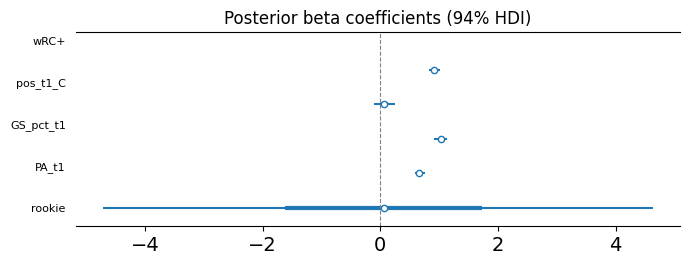

In [83]:
# Coefficient forest plot
fig, ax = plt.subplots(figsize=(7, len(features) * 0.35 + 1))
az.plot_forest(
    trace,
    var_names=['beta'],
    combined=True,
    hdi_prob=0.94,
    ax=ax,
)
ax.set_title('Posterior beta coefficients (94% HDI)')
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features[::-1], fontsize=8)
plt.tight_layout()
plt.show()

## 5. Logistic Regression Model Comparison

Nine Bayesian ordered logistic regressions (bench < platoon < starter) fit on
2017–2023 training data, excluding rookies and pitchers (except Shohei Ohtani).

`starter_t1` is a binary flag: 1 if the player held a **starter** role in the
previous season, 0 otherwise, NaN if no prior-season record exists.

| Model | Features |
|-------|----------|
| M01 | wRC+, starter_t1 |
| M02 | wRC+, starter_t1, PA_t1 |
| M03 | wRC+, PA_t1, GS_pct_t1 |
| M04 | wRC+, same_team_t1, PA_t1, GS_pct_t1 |
| M05 | wRC+, same_team_t1×starter_t1, starter_t1 |
| M06 | wRC+, wRC+_t1, starter_t1 |
| M07 | wRC+, wRC+_t1, starter_t1, Def_t1 |
| M08 | wRC+, wRC+_t1, starter_t1, BsR_t1, Def_t1 |
| M09 | wRC+, wRC+_t1, starter_t1, BsR_t1, Def_t1, same_team_t1×starter_t1 |


In [84]:
OHTANI_IDFG = 19755

# starter_t1: 1 if role in t-1 was 'starter', 0 if another role, NaN if no t-1 data
for _df in [train_mdf, test_mdf]:
    _df['starter_t1'] = (
        (_df['role_t1'] == 'starter')
        .where(_df['role_t1'].notna())
        .astype('Float64')
    )
    _df['same_team_t1_x_starter_t1'] = _df['same_team_t1'] * _df['starter_t1']

# Filter rookies and pitchers (except Ohtani) for these regressions
def prep_for_lr(df: pd.DataFrame) -> pd.DataFrame:
    mask = (df['rookie'] != 1) & (
        (df['primary_pos'] != 'P') | (df['IDfg'] == OHTANI_IDFG)
    )
    return df[mask].copy()

lr_train = prep_for_lr(train_mdf)
lr_test  = prep_for_lr(test_mdf)

print(f'lr_train: {len(lr_train):,} rows  |  lr_test: {len(lr_test):,} rows')
print(f"starter_t1 counts in lr_train: {lr_train['starter_t1'].value_counts(dropna=False).to_dict()}")

# Model specifications — (tag, feature_cols)
LR_SPECS = [
    ('m01', ['wRC+', 'starter_t1']),
    ('m02', ['wRC+', 'starter_t1', 'PA_t1']),
    ('m03', ['wRC+', 'PA_t1', 'GS_pct_t1']),
    ('m04', ['wRC+', 'same_team_t1', 'PA_t1', 'GS_pct_t1']),
    ('m05', ['wRC+', 'same_team_t1_x_starter_t1', 'starter_t1']),
    ('m06', ['wRC+', 'wRC+_t1', 'starter_t1']),
    ('m07', ['wRC+', 'wRC+_t1', 'starter_t1', 'Def_t1']),
    ('m08', ['wRC+', 'wRC+_t1', 'starter_t1', 'BsR_t1', 'Def_t1']),
    ('m09', ['wRC+', 'wRC+_t1', 'starter_t1', 'BsR_t1', 'Def_t1',
             'same_team_t1_x_starter_t1']),
]

print('\nModel specs:')
for tag, feats in LR_SPECS:
    print(f'  {tag.upper()}: {feats}')


lr_train: 3,679 rows  |  lr_test: 542 rows
starter_t1 counts in lr_train: {0.0: 2287, 1.0: 1239, <NA>: 153}

Model specs:
  M01: ['wRC+', 'starter_t1']
  M02: ['wRC+', 'starter_t1', 'PA_t1']
  M03: ['wRC+', 'PA_t1', 'GS_pct_t1']
  M04: ['wRC+', 'same_team_t1', 'PA_t1', 'GS_pct_t1']
  M05: ['wRC+', 'same_team_t1_x_starter_t1', 'starter_t1']
  M06: ['wRC+', 'wRC+_t1', 'starter_t1']
  M07: ['wRC+', 'wRC+_t1', 'starter_t1', 'Def_t1']
  M08: ['wRC+', 'wRC+_t1', 'starter_t1', 'BsR_t1', 'Def_t1']
  M09: ['wRC+', 'wRC+_t1', 'starter_t1', 'BsR_t1', 'Def_t1', 'same_team_t1_x_starter_t1']


In [85]:
lr_results = {}  # tag -> (trace, meta, train_preds, test_preds)

for tag, feats in LR_SPECS:
    run_tag = f'lr_{tag}'
    print(f'\n{"="*60}')
    print(f'Model {tag.upper()}: {feats}')
    print('='*60)

    if (RUNS_DIR / f'{run_tag}_trace.pkl').exists():
        trace_m, meta_m = load_run(run_tag)
    else:
        _, trace_m, meta_m = fit_ordered_logit(
            lr_train,
            feature_cols=feats,
            include_rookies=False,
            n_draws=1000,
            n_tune=1000,
            target_accept=0.9,
            random_seed=42,
        )
        save_run(run_tag, trace_m, meta_m)

    train_p = predict_roles(trace_m, meta_m, lr_train)
    test_p  = predict_roles(trace_m, meta_m, lr_test)
    lr_results[tag] = (trace_m, meta_m, train_p, test_p)
    known_te = test_p[test_p['role_code'].notna()]
    print(f'  Test accuracy: {known_te["correct"].mean():.1%}'
          f'  ({known_te["correct"].sum()} / {len(known_te)})')

print('\nAll 9 models fitted / loaded.')



Model M01: ['wRC+', 'starter_t1']
Fitting on 3,515 observations  (include_rookies=False)
Role distribution:
role
bench      1243
platoon    1083
starter    1189



Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:00<?, ?it/s]


Running chain 0:  15%|█▌        | 300/2000 [00:00<00:00, 2629.50it/s]


Running chain 0:  35%|███▌      | 700/2000 [00:00<00:00, 3105.72it/s]





Running chain 0:  55%|█████▌    | 1100/2000 [00:01<00:00, 3091.31it/s]


Running chain 0:  70%|███████   | 1400/2000 [00:01<00:00, 2780.89it/s]


Running chain 0: 100%|██████████| 2000/2000 [00:01<00:00, 1437.20it/s]
Sampling: [role]


                            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
beta[wRC+]                 0.979  0.051   0.881    1.075      0.001    0.001  3563.180  2730.694  1.001
beta[starter_t1]           2.350  0.082   2.203    2.507      0.001    0.001  3097.774  2827.932  1.002
cutpoint[bench/platoon]   -0.131  0.044  -0.214   -0.049      0.001    0.001  3265.474  2807.121  1.001
cutpoint[platoon/starter]  1.802  0.057   1.685    1.902      0.001    0.001  3177.959  2855.491  1.001

All r_hat <= 1.05  (convergence OK)
Saved 'lr_m01'  ->  /Users/johannhatzius/Desktop/GitHub/personal/classes/LSE/ST451-Bayesian_ML/project/data/model_runs/playing_time/
  features : ['wRC+', 'starter_t1']
  n_obs    : 3,515
  Test accuracy: 59.1%  (304 / 514)

Model M02: ['wRC+', 'starter_t1', 'PA_t1']
Fitting on 3,515 observations  (include_rookies=False)
Role distribution:
role
bench      1243
platoon    1083
starter    1189



Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:00<?, ?it/s]


Running chain 0:  10%|█         | 200/2000 [00:00<00:01, 1727.29it/s]


Running chain 0:  25%|██▌       | 500/2000 [00:01<00:00, 2393.05it/s]


Running chain 0:  45%|████▌     | 900/2000 [00:01<00:00, 2812.41it/s]


Running chain 0:  60%|██████    | 1200/2000 [00:01<00:00, 2751.07it/s]


Running chain 0:  75%|███████▌  | 1500/2000 [00:01<00:00, 2728.23it/s]


Running chain 0: 100%|██████████| 2000/2000 [00:01<00:00, 1290.03it/s]
Sampling: [role]


                            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
beta[wRC+]                 0.854  0.052   0.755    0.950      0.001    0.001  3892.475  2653.732  1.001
beta[starter_t1]           1.725  0.090   1.557    1.889      0.002    0.001  3197.604  2649.010  1.001
beta[PA_t1]                0.772  0.044   0.686    0.852      0.001    0.001  3161.751  3033.787  1.001
cutpoint[bench/platoon]   -0.425  0.049  -0.514   -0.329      0.001    0.001  2599.560  2795.558  1.001
cutpoint[platoon/starter]  1.645  0.059   1.541    1.760      0.001    0.001  3722.357  3043.893  1.002

All r_hat <= 1.05  (convergence OK)
Saved 'lr_m02'  ->  /Users/johannhatzius/Desktop/GitHub/personal/classes/LSE/ST451-Bayesian_ML/project/data/model_runs/playing_time/
  features : ['wRC+', 'starter_t1', 'PA_t1']
  n_obs    : 3,515
  Test accuracy: 63.2%  (325 / 514)

Model M03: ['wRC+', 'PA_t1', 'GS_pct_t1']
Fitting on 3,512 observations  (include_rookies=False)
Role dis

...

                            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
beta[wRC+]                 0.924  0.053   0.831    1.029      0.001    0.001  4031.459  2894.466  1.002
beta[wRC+_t1]              0.359  0.042   0.275    0.435      0.001    0.000  4884.577  3164.366  1.002
beta[starter_t1]           2.244  0.084   2.089    2.407      0.001    0.001  3760.630  3156.386  1.000
beta[Def_t1]               0.175  0.036   0.105    0.239      0.001    0.000  4507.171  2806.265  1.001
cutpoint[bench/platoon]   -0.182  0.046  -0.271   -0.098      0.001    0.001  3604.274  3335.824  1.000
cutpoint[platoon/starter]  1.795  0.057   1.689    1.902      0.001    0.001  4181.444  3714.612  1.000

All r_hat <= 1.05  (convergence OK)
Saved 'lr_m07'  ->  /Users/johannhatzius/Desktop/GitHub/personal/classes/LSE/ST451-Bayesian_ML/project/data/model_runs/playing_time/
  features : ['wRC+', 'wRC+_t1', 'starter_t1', 'Def_t1']
  n_obs    : 3,512
  Test accuracy: 61.7%  (3

Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:  15%|█▌        | 300/2000 [00:00<00:00, 2484.53it/s]


Running chain 0:  30%|███       | 600/2000 [00:00<00:00, 2460.08it/s]


Running chain 0:  45%|████▌     | 900/2000 [00:01<00:00, 2637.24it/s]


Running chain 0:  60%|██████    | 1200/2000 [00:01<00:00, 2691.07it/s]

Running chain 0:  90%|█████████ | 1800/2000 [00:01<00:00, 2782.53it/s]


Running chain 0: 100%|██████████| 2000/2000 [00:01<00:00, 1382.05it/s]

Running chain 1: 100%|██████████| 2000/2000 [00:01<00:00, 1282.92it/s]
Sampling: [role]


                            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
beta[wRC+]                 0.925  0.053   0.822    1.021      0.001    0.001  4064.038  2506.393  1.002
beta[wRC+_t1]              0.357  0.042   0.280    0.438      0.001    0.000  5133.532  3094.034  1.001
beta[starter_t1]           2.249  0.085   2.089    2.411      0.001    0.001  3460.861  2854.986  1.001
beta[BsR_t1]              -0.034  0.037  -0.103    0.033      0.001    0.000  4523.465  3101.892  1.001
beta[Def_t1]               0.183  0.036   0.111    0.249      0.001    0.000  4414.095  3048.320  1.001
cutpoint[bench/platoon]   -0.179  0.045  -0.263   -0.094      0.001    0.001  3237.407  2947.169  1.001
cutpoint[platoon/starter]  1.798  0.060   1.685    1.905      0.001    0.001  3776.771  3389.376  1.001

All r_hat <= 1.05  (convergence OK)
Saved 'lr_m08'  ->  /Users/johannhatzius/Desktop/GitHub/personal/classes/LSE/ST451-Bayesian_ML/project/data/model_runs/playing_time

Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:00<?, ?it/s]


Running chain 0:  10%|█         | 200/2000 [00:00<00:01, 1695.91it/s]



Running chain 0:  25%|██▌       | 500/2000 [00:01<00:00, 1932.19it/s]


Running chain 0:  40%|████      | 800/2000 [00:01<00:00, 2036.94it/s]


Running chain 0:  65%|██████▌   | 1300/2000 [00:01<00:00, 1936.58it/s]


Running chain 0:  75%|███████▌  | 1500/2000 [00:01<00:00, 1886.38it/s]


Running chain 0:  85%|████████▌ | 1700/2000 [00:01<00:00, 1861.03it/s]


Running chain 1: 100%|██████████| 2000/2000 [00:01<00:00, 1111.25it/s]

Running chain 0: 100%|██████████| 2000/2000 [00:01<00:00, 1087.72it/s]








Running chain 3: 100%|██████████| 2000/2000 [00:02<00:00, 818.42it/s] 
Sampling: [role]


                                  mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
beta[wRC+]                       0.920  0.052   0.825    1.020      0.001    0.001  4841.583  2869.051  1.000
beta[wRC+_t1]                    0.358  0.042   0.279    0.436      0.001    0.000  5040.681  2986.052  1.000
beta[starter_t1]                 2.016  0.114   1.813    2.248      0.002    0.001  4045.065  2920.767  1.002
beta[BsR_t1]                    -0.036  0.038  -0.105    0.036      0.001    0.000  4265.891  3032.829  1.001
beta[Def_t1]                     0.181  0.037   0.116    0.250      0.001    0.000  3917.517  2853.310  1.002
beta[same_team_t1_x_starter_t1]  0.368  0.128   0.126    0.599      0.002    0.001  4000.246  3134.949  1.001
cutpoint[bench/platoon]         -0.190  0.045  -0.270   -0.106      0.001    0.000  4701.474  3254.714  1.001
cutpoint[platoon/starter]        1.793  0.059   1.685    1.905      0.001    0.001  5102.641  3334.747  1.001

All r_hat

In [87]:
# Coefficient table — posterior means (standardised); — = not in model
FEAT_DISPLAY = {'same_team_t1_x_starter_t1': 'same_team_t1×starter_t1'}

# Collect all features in appearance order across all specs
all_feats_ordered = []
for _, feats in LR_SPECS:
    for f in feats:
        d = FEAT_DISPLAY.get(f, f)
        if d not in all_feats_ordered:
            all_feats_ordered.append(d)

rows = []
for tag, (trace_m, meta_m, _, _) in lr_results.items():
    beta_draws = trace_m.posterior['beta'].values.reshape(-1, len(meta_m['feature_cols']))
    beta_means = beta_draws.mean(axis=0)
    row = {'Model': tag.upper()}
    for feat, bm in zip(meta_m['feature_cols'], beta_means):
        row[FEAT_DISPLAY.get(feat, feat)] = round(float(bm), 3)
    rows.append(row)

coef_df = pd.DataFrame(rows).set_index('Model').reindex(columns=all_feats_ordered)

print('Posterior mean β coefficients (z-scored continuous features; — = not in model)\n')
print(coef_df.to_string(float_format='{:.3f}'.format, na_rep='—'))


Posterior mean β coefficients (z-scored continuous features; — = not in model)

       wRC+  starter_t1  PA_t1  GS_pct_t1  same_team_t1  same_team_t1×starter_t1  wRC+_t1  Def_t1  BsR_t1
Model                                                                                                    
M01   0.979       2.350      —          —             —                        —        —       —       —
M02   0.854       1.725  0.772          —             —                        —        —       —       —
M03   0.918           —  0.658      1.035             —                        —        —       —       —
M04   0.913           —  0.644      1.027         0.238                        —        —       —       —
M05   0.973       2.104      —          —             —                    0.384        —       —       —
M06   0.906       2.231      —          —             —                        —    0.335       —       —
M07   0.924       2.244      —          —             —                 

In [88]:
def log_score(preds_df: pd.DataFrame) -> float:
    """Mean log predictive probability over rows with a known role."""
    known = preds_df[preds_df['role_code'].notna()].copy()
    prob_mat = np.column_stack([known[f'p_{r}'] for r in ROLE_ORDER])
    idx = known['role_code'].astype(int).values
    actual_p = prob_mat[np.arange(len(known)), idx]
    return float(np.mean(np.log(np.maximum(actual_p, 1e-10))))

acc_rows = []
for tag, (_, _, train_p, test_p) in lr_results.items():
    ktr = train_p[train_p['role_code'].notna()]
    kte = test_p[test_p['role_code'].notna()]
    acc_rows.append({
        'Model':           tag.upper(),
        'Train Acc':       f"{ktr['correct'].mean():.1%}",
        'Test Acc':        f"{kte['correct'].mean():.1%}",
        'Train Log Score': f"{log_score(ktr):.4f}",
        'Test Log Score':  f"{log_score(kte):.4f}",
        'Train N':         len(ktr),
        'Test N':          len(kte),
    })

acc_df = pd.DataFrame(acc_rows).set_index('Model')

print('Model accuracy and mean log score  (2017–2023 train / 2024 test)\n')
print(acc_df.to_string())


Model accuracy and mean log score  (2017–2023 train / 2024 test)

      Train Acc Test Acc Train Log Score Test Log Score  Train N  Test N
Model                                                                   
M01       59.9%    59.1%         -0.8477        -0.8434     3515     514
M02       63.0%    63.2%         -0.8040        -0.8168     3515     514
M03       63.4%    60.4%         -0.8041        -0.8450     3512     513
M04       63.5%    59.4%         -0.8018        -0.8466     3492     512
M05       59.9%    59.2%         -0.8466        -0.8406     3492     512
M06       60.8%    61.5%         -0.8370        -0.8342     3512     514
M07       61.6%    61.7%         -0.8336        -0.8319     3512     514
M08       61.5%    61.3%         -0.8335        -0.8318     3512     514
M09       61.6%    61.9%         -0.8325        -0.8317     3489     512


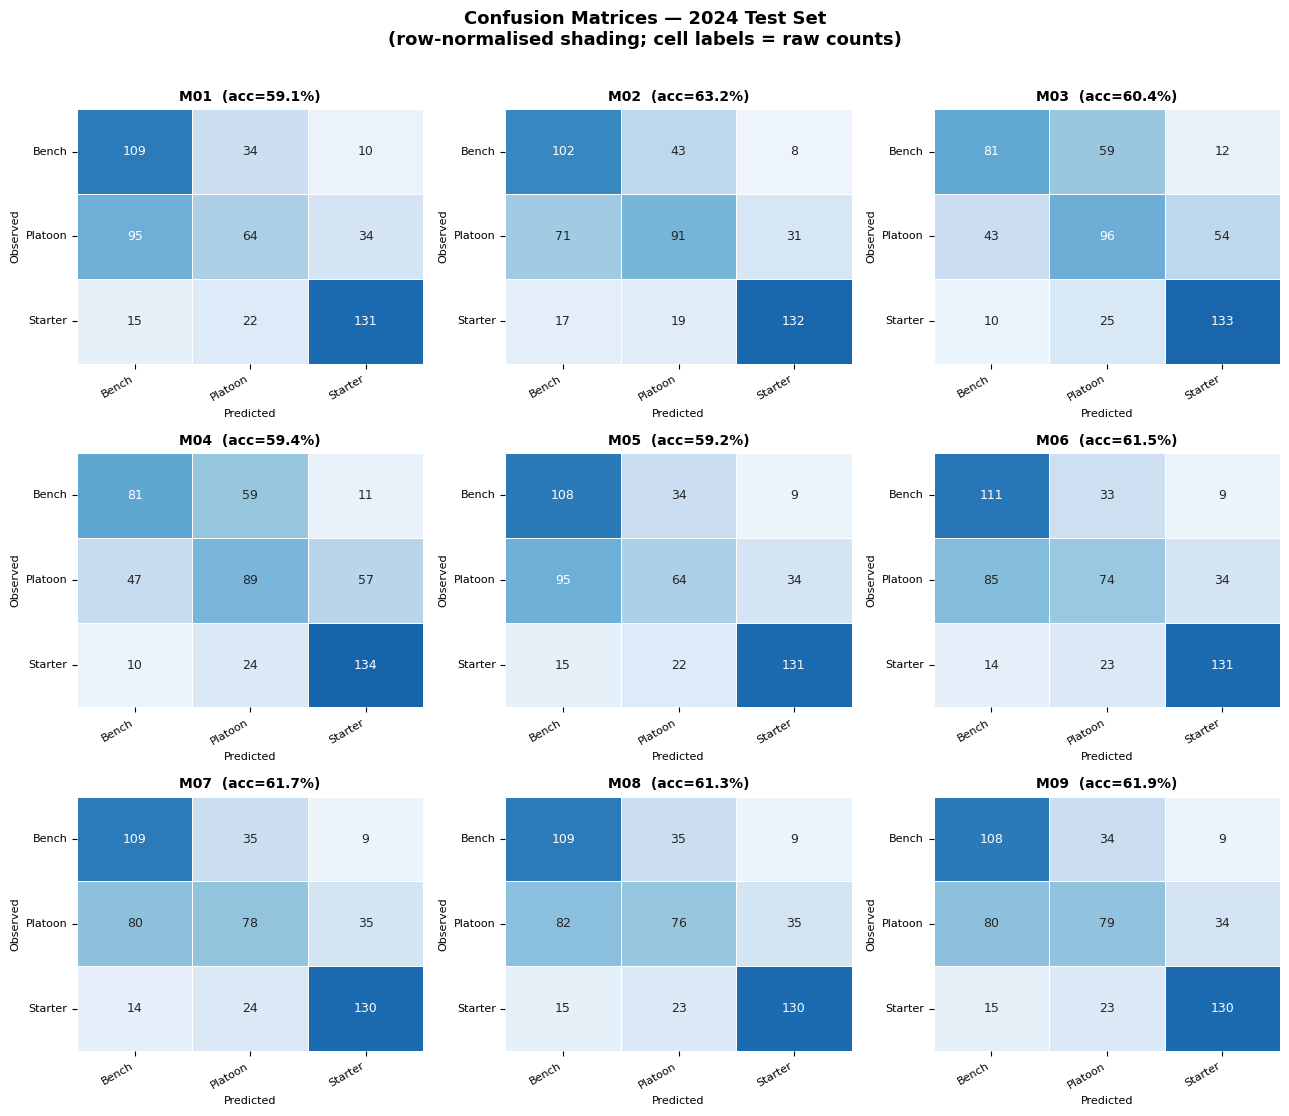

In [89]:
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(13, 11))
fig.suptitle(
    'Confusion Matrices — 2024 Test Set\n(row-normalised shading; cell labels = raw counts)',
    fontsize=13, y=1.01, fontweight='bold',
)

for ax, (tag, (_, _, _, test_p)) in zip(axes.flat, lr_results.items()):
    known = test_p[test_p['role_code'].notna()]
    cm_raw = pd.crosstab(
        known['role'], known['pred_role'],
        rownames=['Obs'], colnames=['Pred'],
    ).reindex(index=ROLE_ORDER, columns=ROLE_ORDER, fill_value=0)

    cm_norm = cm_raw.div(cm_raw.sum(axis=1), axis=0)
    acc = known['correct'].mean()

    sns.heatmap(
        cm_norm,
        annot=cm_raw.values,
        fmt='d',
        cmap='Blues',
        vmin=0, vmax=1,
        cbar=False,
        ax=ax,
        linewidths=0.5,
        annot_kws={'size': 9},
    )
    ax.set_title(f'{tag.upper()}  (acc={acc:.1%})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Observed',  fontsize=8)
    ax.tick_params(labelsize=8)
    ax.set_xticklabels([r.capitalize() for r in ROLE_ORDER], rotation=30, ha='right')
    ax.set_yticklabels([r.capitalize() for r in ROLE_ORDER], rotation=0)

plt.tight_layout()
plt.show()
